In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, f1_score
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score
from imblearn.pipeline import Pipeline as pipeline2
from imblearn.over_sampling import SMOTE, ADASYN


In [19]:
# Cargar el archivo
df = pd.read_csv('violencia_unite_data.csv')

# Convertir 'CONDUCENTE' a binario: 1.0 -> 1, 2.0 o 9.0 -> 0
df['CONDUCENTE'] = df['CONDUCENTE'].replace({2.0: 0, 9.0: 0})

# Eliminar filas con valores nulos en la variable objetivo
df = df.dropna(subset=['CONDUCENTE'])

#submuestreo

#separar por clase
df_1 = df[df['CONDUCENTE'] == 1]
df_0 = df[df['CONDUCENTE'] == 0]

# Submuestreo de la clase mayoritaria (1.0)
df_1_downsampled = df_1.sample(len(df_0), random_state=42)

# Unir los conjuntos balanceados
df = pd.concat([df_1_downsampled, df_0])

# Mezclar el dataframe
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.value_counts('CONDUCENTE')

CONDUCENTE
0.0    8038
1.0    8038
Name: count, dtype: int64

In [20]:
# Variable objetivo
y = df['CONDUCENTE']

# Selección de características
X = df[[
    'REP_DEP', 'REP_MUNI', 'VIC_SEXO', 'VIC_EDAD',
    'AGR_SEXO', 'AGR_EDAD', 'VIC_GRUPET', 'AGR_GRUPET',
    'VIC_NACIONAL', 'AGR_NACIONAL', 'VIC_OCUP', 'AGR_OCUP',
    'HEC_DEP', 'HEC_MUNI', 'HEC_AREA'
]]


In [21]:
# Separar columnas categóricas y numéricas
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(exclude='object').columns.tolist()

# Crear transformador de columnas
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'  # Deja pasar columnas numéricas tal cual
)


In [22]:
# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (12860, 15), Test: (3216, 15)


In [23]:
# Pipeline con preprocesamiento y regresión logística
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Entrenar el modelo
model.fit(X_train, y_train)

c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['REP_DEP', 'REP_MUNI',
                                                   'VIC_SEXO', 'AGR_SEXO',
                                                   'VIC_GRUPET', 'AGR_GRUPET',
                                                   'VIC_NACIONAL',
                                                   'AGR_NACIONAL', 'VIC_OCUP',
                                                   'AGR_OCUP', 'HEC_DEP',
                                                   'HEC_MUNI', 'HEC_AREA'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [24]:
# Predicciones
y_pred = model.predict(X_test)

# Evaluación
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Classification Report:
               precision    recall  f1-score   support

         0.0       0.63      0.65      0.64      1578
         1.0       0.66      0.63      0.64      1638

    accuracy                           0.64      3216
   macro avg       0.64      0.64      0.64      3216
weighted avg       0.64      0.64      0.64      3216



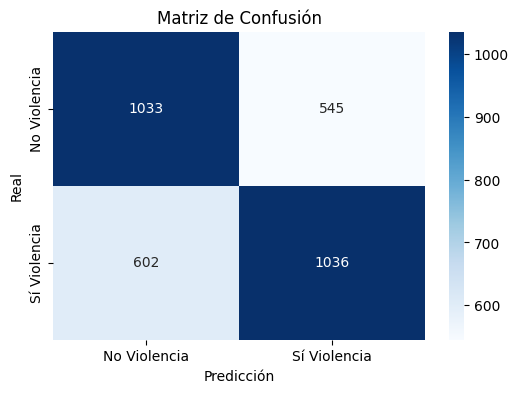

In [25]:
# Generar matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Visualización
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Violencia", "Sí Violencia"],
            yticklabels=["No Violencia", "Sí Violencia"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

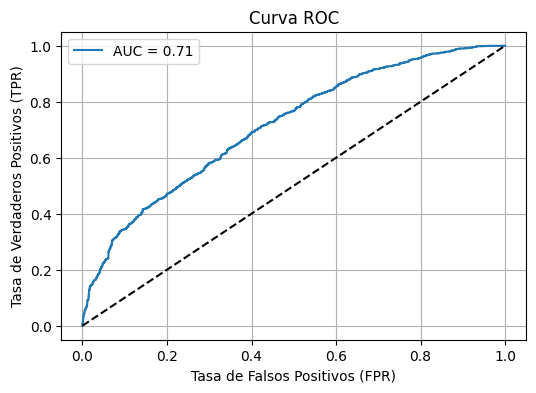

In [26]:
# Obtener probabilidades de clase positiva
y_prob = model.predict_proba(X_test)[:, 1]

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

# Visualización
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')  # Línea base
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.grid(True)
plt.show()


## Normalización

In [27]:
# Variables numéricas y categóricas
num_features = ['VIC_EDAD', 'AGR_EDAD', 'VIC_EDADMUJ', 'VIC_EDADHOM', 'AGR_EDADMUJ', 'AGR_EDADHOM']
cat_features = ['REP_DEP', 'REP_MUNI', 'VIC_SEXO', 'AGR_SEXO', 'VIC_GRUPET', 'AGR_GRUPET',
                'VIC_NACIONAL', 'AGR_NACIONAL', 'VIC_OCUP', 'AGR_OCUP', 'HEC_DEP', 'HEC_MUNI', 'HEC_AREA']

# Preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

# Modelo
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])


In [28]:
sexo_edad_cols = ['VIC_EDADMUJ', 'VIC_EDADHOM', 'AGR_EDADMUJ', 'AGR_EDADHOM']
df[sexo_edad_cols] = df[sexo_edad_cols].fillna(0)

# Separar X e y
X = df.drop('CONDUCENTE', axis=1)
y = df['CONDUCENTE'].replace({2.0: 0.0, 9.0: 0.0, 1.0: 1.0})  # Asegura que las clases estén bien definidas

# División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# Entrenar
model.fit(X_train, y_train)

# Evaluar
y_pred = model.predict(X_test)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ROC
y_prob = model.predict_proba(X_test)[:, 1]
print(f"\nROC AUC Score: {roc_auc_score(y_test, y_prob):.2f}")


Confusion Matrix:
 [[1550  862]
 [ 919 1492]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.63      0.64      0.64      2412
         1.0       0.63      0.62      0.63      2411

    accuracy                           0.63      4823
   macro avg       0.63      0.63      0.63      4823
weighted avg       0.63      0.63      0.63      4823


ROC AUC Score: 0.70


In [29]:
print(df['CONDUCENTE'].value_counts(normalize=True))

CONDUCENTE
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64



Confusion Matrix:
 [[1246 1166]
 [ 627 1784]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.67      0.52      0.58      2412
         1.0       0.60      0.74      0.67      2411

    accuracy                           0.63      4823
   macro avg       0.63      0.63      0.62      4823
weighted avg       0.64      0.63      0.62      4823


ROC AUC Score: 0.7028313258813084


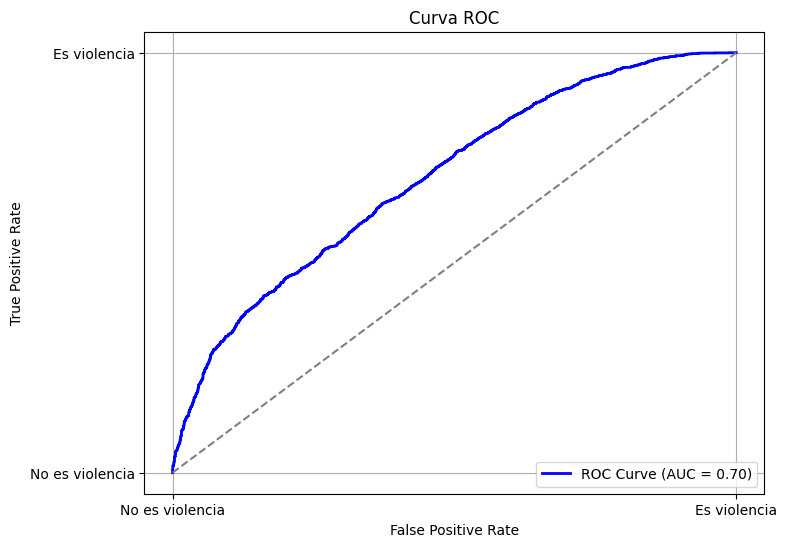

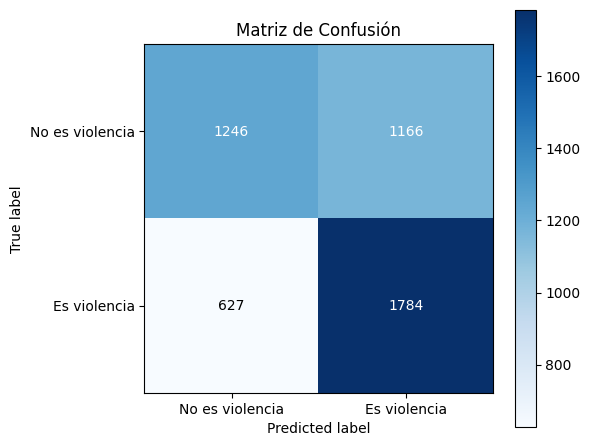

In [30]:
# Obtener las probabilidades de clase positiva
y_proba = model.predict_proba(X_test)[:, 1]

# Ajustar el umbral (por ejemplo, 0.4 en vez de 0.5)
umbral = 0.46
y_pred = (y_proba >= umbral).astype(int)

# Evaluar el modelo
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC AUC Score:", roc_auc_score(y_test, y_proba))

# --- GRÁFICA ROC ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot(["No es violencia", "Es violencia"], ["No es violencia", "Es violencia"], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# --- MATRIZ DE CONFUSIÓN ---
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.colorbar()
classes = ["No es violencia", "Es violencia"]
plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)

# Etiquetas de la matriz de confusión
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center", color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()


## Cross validation

In [31]:
# Identificar columnas numéricas y categóricas
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

# Pipeline para variables numéricas
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Pipeline para variables categóricas
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Unir los pipelines con ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# Pipeline completo
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))
])

# Aplicar validación cruzada con 5 particiones (folds)
cv_scores = cross_val_score(full_pipeline, X_train, y_train, cv=5, scoring='accuracy')

# Mostrar resultados
print("Accuracy en cada fold de validación cruzada:", cv_scores)
print("Accuracy promedio:", cv_scores.mean())


Accuracy en cada fold de validación cruzada: [0.63171924 0.63749445 0.63349622 0.64977778 0.63777778]
Accuracy promedio: 0.638053092452737



Confusion Matrix:
 [[1570  842]
 [ 933 1478]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.63      0.65      0.64      2412
         1.0       0.64      0.61      0.62      2411

    accuracy                           0.63      4823
   macro avg       0.63      0.63      0.63      4823
weighted avg       0.63      0.63      0.63      4823


ROC AUC Score: 0.7026568732447261


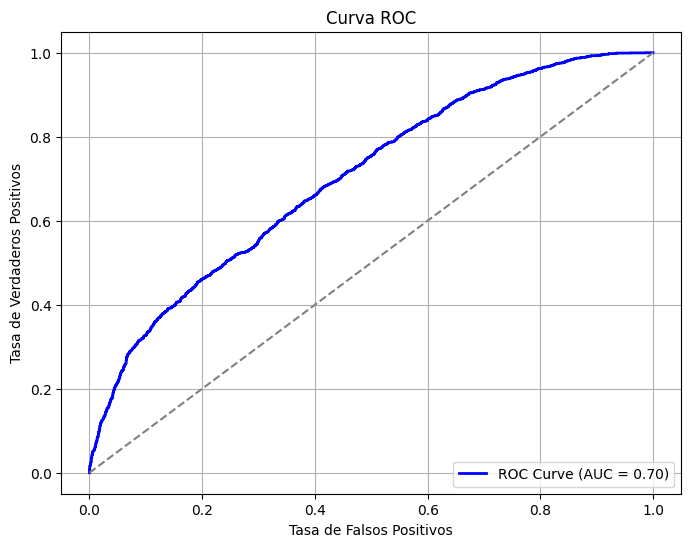

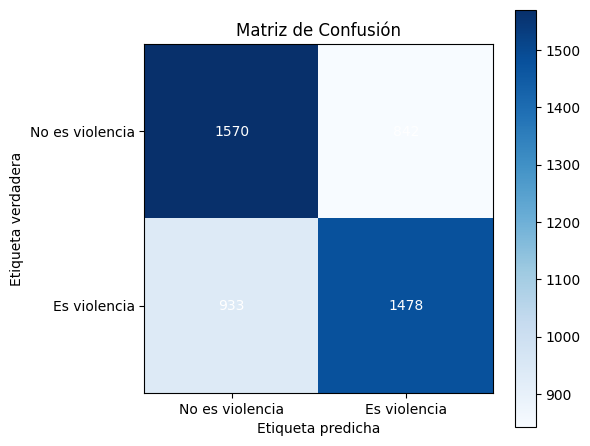

In [32]:
# Asegurarse de que el pipeline esté entrenado antes de predecir
full_pipeline.fit(X_train, y_train)

# Predecir probabilidades con el pipeline entrenado
y_proba = full_pipeline.predict_proba(X_test)[:, 1]

# Ajustar el umbral
umbral = 0.5
y_pred = (y_proba >= umbral).astype(int)

# Evaluar el modelo
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC AUC Score:", roc_auc_score(y_test, y_proba))

# --- GRÁFICA ROC ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# --- MATRIZ DE CONFUSIÓN ---
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.colorbar()
classes = ["No es violencia", "Es violencia"]
plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)

# Etiquetas en cada celda
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel('Etiqueta verdadera')
plt.xlabel('Etiqueta predicha')
plt.tight_layout()
plt.show()

In [33]:
# División previa de los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Identificar columnas numéricas y categóricas
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

# Pipeline para variables numéricas
num_pipeline = pipeline2([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Pipeline para variables categóricas
cat_pipeline = pipeline2([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Unir los pipelines con ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# Pipeline completo
full_pipeline = pipeline2([
    ('preprocessor', preprocessor),
    ('logreg', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# Validación cruzada
cv_scores = cross_val_score(full_pipeline, X_train, y_train, cv=5, scoring='f1')

In [36]:
# Asegúrate de que el pipeline esté entrenado antes de predecir
full_pipeline.fit(X_train, y_train)

y_prob = full_pipeline.predict_proba(X_test)[:, 1]

mejor_f1 = 0
mejor_umbral = 0.5

for u in np.arange(0.1, 0.9, 0.01):
    y_pred_u = (y_prob >= u).astype(int)
    f1 = f1_score(y_test, y_pred_u, average='macro')
    if f1 > mejor_f1:
        mejor_f1 = f1
        mejor_umbral = u

print(f"Mejor umbral: {mejor_umbral:.2f}, con macro F1-score: {mejor_f1:.4f}")

Mejor umbral: 0.49, con macro F1-score: 0.6414


In [37]:
# Entrenar
full_pipeline.fit(X_train, y_train)

# Predecir y evaluar
y_proba = full_pipeline.predict_proba(X_test)[:, 1]
umbral = mejor_umbral
y_pred = (y_proba >= umbral).astype(int)

print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC AUC Score:", roc_auc_score(y_test, y_proba))


Matriz de confusión:
 [[ 960  618]
 [ 533 1105]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.64      0.61      0.63      1578
         1.0       0.64      0.67      0.66      1638

    accuracy                           0.64      3216
   macro avg       0.64      0.64      0.64      3216
weighted avg       0.64      0.64      0.64      3216


ROC AUC Score: 0.7129621891979308


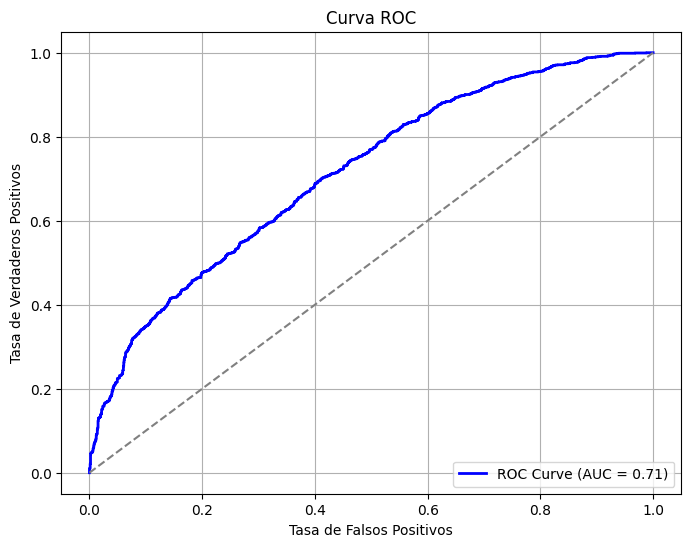

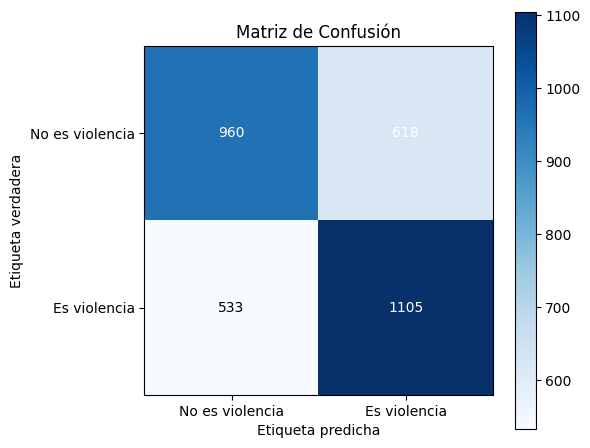

In [38]:
# --- GRÁFICA ROC ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# --- MATRIZ DE CONFUSIÓN ---
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.colorbar()
classes = ["No es violencia", "Es violencia"]
plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)

# Etiquetas en cada celda
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel('Etiqueta verdadera')
plt.xlabel('Etiqueta predicha')
plt.tight_layout()
plt.show()

## RANDOM FOREST

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

# Usa SMOTE en vez de ADASYN para mayor robustez en cross-validation
full_pipeline_rf = pipeline2([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, 
                                  class_weight='balanced',
                                  random_state=42))
])

# Validación cruzada estratificada (usa F1 macro)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(full_pipeline_rf, X_train, y_train, cv=cv, scoring='f1_macro', error_score=np.nan)
print("F1 macro promedio:", np.nanmean(cv_scores))

# Entrenar
full_pipeline_rf.fit(X_train, y_train)

# Predecir
y_proba = full_pipeline_rf.predict_proba(X_test)[:, 1]

# Buscar mejor umbral (F1 macro)
mejor_f1 = 0
mejor_umbral = 0.5
for u in np.arange(0.1, 0.9, 0.01):
    y_pred_u = (y_proba >= u).astype(int)
    f1 = f1_score(y_test, y_pred_u, average='macro')
    if f1 > mejor_f1:
        mejor_f1 = f1
        mejor_umbral = u

print(f"Mejor umbral: {mejor_umbral:.2f}, con macro F1-score: {mejor_f1:.4f}")


F1 macro promedio: 0.6183681469300837
Mejor umbral: 0.51, con macro F1-score: 0.6250



Matriz de confusión:
 [[1002  576]
 [ 630 1008]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.61      0.63      0.62      1578
         1.0       0.64      0.62      0.63      1638

    accuracy                           0.62      3216
   macro avg       0.63      0.63      0.62      3216
weighted avg       0.63      0.62      0.63      3216


ROC AUC Score: 0.6772949097093584


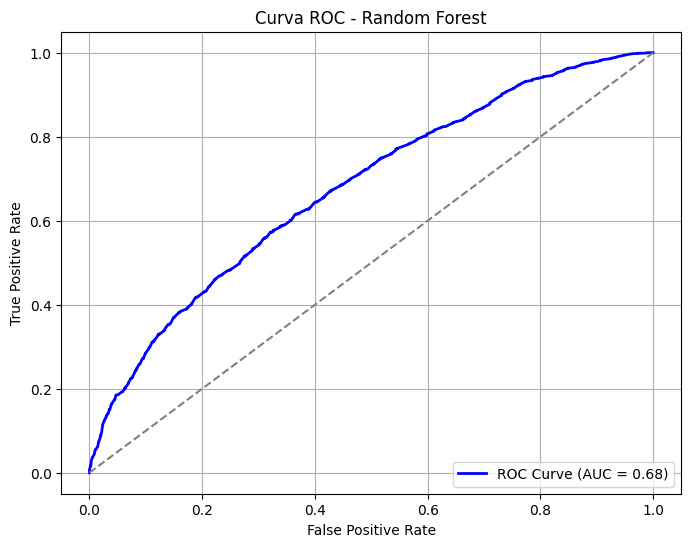

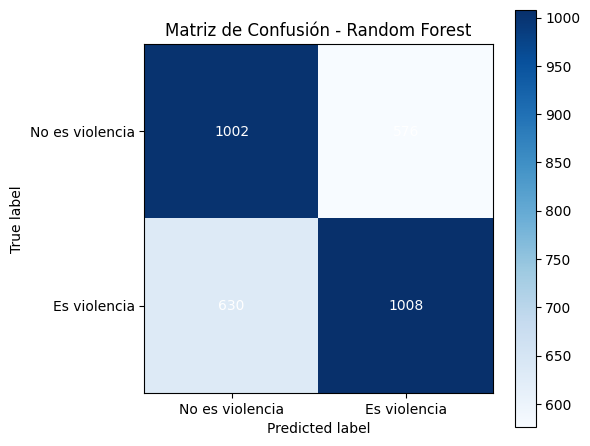

In [43]:
# Aplicar mejor umbral
y_pred = (y_proba >= mejor_umbral).astype(int)

# Resultados en texto
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC AUC Score:", roc_auc_score(y_test, y_proba))

# --- GRÁFICA ROC ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# --- MATRIZ DE CONFUSIÓN GRÁFICA ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - Random Forest')
plt.colorbar()

classes = ["No es violencia", "Es violencia"]
plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)

# Etiquetas en cada celda
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()